In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ======================================
#   ASD-FIC FULL IMPLEMENTATION (Colab)
#   Correctly supports: train/valid/test
#   VGG19 + DATA AUG + TRAIN + LIME
# ======================================

import os
import numpy as np
import matplotlib.pyplot as plt
import json

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import GlobalMaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

!pip install lime opencv-python -q
from lime import lime_image
import cv2
from skimage.segmentation import mark_boundaries


# =====================================================
#                BUILD MODEL
# =====================================================
def build_vgg19(input_shape=(224,224,3), n_classes=2, dropout=0.5, trainable_blocks=1):

    base = VGG19(weights="imagenet", include_top=False, input_shape=input_shape)

    # Freeze all layers
    for layer in base.layers:
        layer.trainable = False

    # Unfreeze last convolution blocks
    blocks = ["block5", "block4", "block3", "block2", "block1"]
    for layer in base.layers:
        for b in blocks[:trainable_blocks]:
            if layer.name.startswith(b):
                layer.trainable = True

    x = base.output
    x = GlobalMaxPooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout)(x)

    outputs = Dense(n_classes, activation="softmax")(x)

    model = Model(base.input, outputs)
    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =====================================================
#                DATA LOADING
# =====================================================
def load_data(data_dir, img_size=(224,224), batch=32):

    train_datagen = ImageDataGenerator(
        rescale=1/255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.1,
        horizontal_flip=True
    )

    test_datagen = ImageDataGenerator(rescale=1/255)

    train_gen = train_datagen.flow_from_directory(
        data_dir + "/train",
        target_size=img_size,
        batch_size=batch,
        class_mode="categorical",
        shuffle=True
    )

    val_gen = test_datagen.flow_from_directory(
        data_dir + "/valid",    # ✔ FIXED FOR YOUR DATA
        target_size=img_size,
        batch_size=batch,
        class_mode="categorical",
        shuffle=False
    )

    test_gen = test_datagen.flow_from_directory(
        data_dir + "/test",
        target_size=img_size,
        batch_size=batch,
        class_mode="categorical",
        shuffle=False
    )

    return train_gen, val_gen, test_gen


# =====================================================
#                TRAIN FUNCTION
# =====================================================
def train_model(data_dir="./dataset", epochs=30, batch_size=32):

    train_gen, val_gen, test_gen = load_data(data_dir, batch=batch_size)

    model = build_vgg19(
        input_shape=(224,224,3),
        n_classes=train_gen.num_classes,
        trainable_blocks=1
    )

    print("\nClass indices:", train_gen.class_indices)
    json.dump(train_gen.class_indices, open("class_indices.json","w"))

    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
        ModelCheckpoint("asd_vgg19.h5", save_best_only=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks
    )

    print("\nTraining completed. Model saved as asd_vgg19.h5")
    print("\nEvaluating on test set…")

    evaluate(model, test_gen)

    return model, history


# =====================================================
#                EVALUATION
# =====================================================
def evaluate(model, generator):

    y_true = generator.classes
    preds = model.predict(generator)
    y_pred = np.argmax(preds, axis=1)

    target_names = list(json.load(open("class_indices.json")).keys())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# =====================================================
#                LIME EXPLAINABILITY
# =====================================================
def explain(image_path, model_path="asd_vgg19.h5"):

    print("Loading model...")
    model = load_model(model_path)

    class_map = json.load(open("class_indices.json"))
    class_map_inv = {v:k for k,v in class_map.items()}

    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224,224))
    x = tf.keras.preprocessing.image.img_to_array(img)
    x_norm = x/255.0
    x_batch = np.expand_dims(x_norm, 0)

    preds = model.predict(x_batch)[0]
    pred_cls = np.argmax(preds)

    print("Prediction:", class_map_inv[pred_cls], "| Probability:", preds[pred_cls])

    def predict_fn(images):
        return model.predict(np.array(images))

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        x_norm.astype("double"),
        predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        label=pred_cls,
        positive_only=False,
        num_features=5,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation")
    plt.axis("off")
    plt.show()


# =====================================================
#             HOW TO USE (UNCOMMENT)
# =====================================================

# 1) Train model:
# model, history = train_model(
#     data_dir="/content/drive/MyDrive/Graduation Project/face/dataset",
#     epochs=30,
#     batch_size=32
# )

# 2) Explain a single image:
# explain("/content/drive/MyDrive/Graduation Project/face/dataset/test/autistic/image1.jpg")


In [ ]:
import os

base = "/content/drive/MyDrive/Graduation Project/face/dataset"

for folder in ["train", "valid", "test"]:
    print(f"\nChecking: {folder}")
    path = os.path.join(base, folder)
    for sub in ["autistic", "non_autistic"]:
        full = os.path.join(path, sub)
        if os.path.exists(full):
            print(f" {sub}: {len(os.listdir(full))} images")
        else:
            print(f" {sub}: MISSING ❌")



Checking: train
 autistic: 1268 images
 non_autistic: 1268 images

Checking: valid
 autistic: 50 images
 non_autistic: 50 images

Checking: test
 autistic: 150 images
 non_autistic: 150 images


In [ ]:
# 1) Train model:
model, history = train_model(
    data_dir="/content/drive/MyDrive/Graduation Project/face/dataset",
    epochs=30,
    batch_size=32
)

Found 2536 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 300 images belonging to 2 classes.

Class indices: {'autistic': 0, 'non_autistic': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.5518 - loss: 1.2089

80/80 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5521 - loss: 1.2068 - val_accuracy: 0.6000 - val_loss: 0.7368 - learning_rate: 1.0000e-04
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.6142 - loss: 0.7483

80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 563ms/step - accuracy: 0.6143 - loss: 0.7478 - val_accuracy: 0.7300 - val_loss: 0.5164 - learning_rate: 1.0000e-04
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 562ms/step - accuracy: 0.6738 - loss: 0.6296 - val_accuracy: 0.6100 - val_loss: 0.7671 - learning_rate: 1.0000e-04
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 560ms/step - accuracy: 0.6739 - loss: 0.6123 - val_accuracy: 0.6600 - val_loss: 0.5955 - learning_rate: 1.0000e-04
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 555ms/step - accuracy: 0.6977 - loss: 0.5852 - val_accuracy: 0.6900 - val_loss: 0.5544 - learning_rate: 1.0000e-04
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.7167 - loss: 0.5677

...

80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 571ms/step - accuracy: 0.7265 - loss: 0.5291 - val_accuracy: 0.7700 - val_loss: 0.4874 - learning_rate: 1.0000e-04
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 559ms/step - accuracy: 0.7473 - loss: 0.5068 - val_accuracy: 0.7200 - val_loss: 0.7111 - learning_rate: 1.0000e-04
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 559ms/step - accuracy: 0.7583 - loss: 0.4921 - val_accuracy: 0.6400 - val_loss: 0.8173 - learning_rate: 1.0000e-04
Epoch 10/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7846 - loss: 0.4714

80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 561ms/step - accuracy: 0.7845 - loss: 0.4717 - val_accuracy: 0.7600 - val_loss: 0.4576 - learning_rate: 1.0000e-04
Epoch 11/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 559ms/step - accuracy: 0.7887 - loss: 0.4436 - val_accuracy: 0.6700 - val_loss: 0.6326 - learning_rate: 1.0000e-04
Epoch 12/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 548ms/step - accuracy: 0.7786 - loss: 0.4539 - val_accuracy: 0.7000 - val_loss: 0.6392 - learning_rate: 1.0000e-04
Epoch 13/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 553ms/step - accuracy: 0.7921 - loss: 0.4436 - val_accuracy: 0.6900 - val_loss: 0.7801 - learning_rate: 1.0000e-04
Epoch 14/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 554ms/step - accuracy: 0.7936 - loss: 0.4199 - val_accuracy: 0.6800 - val_loss: 0.6444 - learning_rate: 1.0000e-04
Epoch 15/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8209 - loss: 0.4012

80/80 ━━━━━━━━━━━━━━━━━━━━ 85s 592ms/step - accuracy: 0.8208 - loss: 0.4014 - val_accuracy: 0.8300 - val_loss: 0.4419 - learning_rate: 1.0000e-04
Epoch 16/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 550ms/step - accuracy: 0.8388 - loss: 0.3837 - val_accuracy: 0.7900 - val_loss: 0.4440 - learning_rate: 1.0000e-04
Epoch 17/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 560ms/step - accuracy: 0.8304 - loss: 0.4166 - val_accuracy: 0.7600 - val_loss: 0.6156 - learning_rate: 1.0000e-04
Epoch 18/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 541ms/step - accuracy: 0.8329 - loss: 0.3989 - val_accuracy: 0.6900 - val_loss: 0.6585 - learning_rate: 1.0000e-04
Epoch 19/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 548ms/step - accuracy: 0.8336 - loss: 0.3696 - val_accuracy: 0.7600 - val_loss: 0.4535 - learning_rate: 1.0000e-04
Epoch 20/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 553ms/step - accuracy: 0.8424 - loss: 0.3680 - val_accuracy: 0.7400 - val_loss: 0.5795 - learning_rate: 1.0000e-04
Epoch 21/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 545ms/step - accuracy

80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 547ms/step - accuracy: 0.8645 - loss: 0.3072 - val_accuracy: 0.8000 - val_loss: 0.4060 - learning_rate: 5.0000e-05
Epoch 24/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 545ms/step - accuracy: 0.8802 - loss: 0.2843 - val_accuracy: 0.8100 - val_loss: 0.4439 - learning_rate: 5.0000e-05
Epoch 25/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.8850 - loss: 0.2935

80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 548ms/step - accuracy: 0.8850 - loss: 0.2934 - val_accuracy: 0.8300 - val_loss: 0.3723 - learning_rate: 5.0000e-05
Epoch 26/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 539ms/step - accuracy: 0.8860 - loss: 0.2655 - val_accuracy: 0.8300 - val_loss: 0.5517 - learning_rate: 5.0000e-05
Epoch 27/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 547ms/step - accuracy: 0.9027 - loss: 0.2568 - val_accuracy: 0.7800 - val_loss: 0.7036 - learning_rate: 5.0000e-05
Epoch 28/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 539ms/step - accuracy: 0.9006 - loss: 0.2470 - val_accuracy: 0.7800 - val_loss: 0.4594 - learning_rate: 5.0000e-05
Epoch 29/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 536ms/step - accuracy: 0.8952 - loss: 0.2443 - val_accuracy: 0.7600 - val_loss: 0.9279 - learning_rate: 5.0000e-05
Epoch 30/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 536ms/step - accuracy: 0.8991 - loss: 0.2608 - val_accuracy: 0.7700 - val_loss: 0.5257 - learning_rate: 5.0000e-05

Training completed. Model saved as asd_vgg19.h5

Evaluating on 

Loading model...


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: autistic | Probability: 0.9154213


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

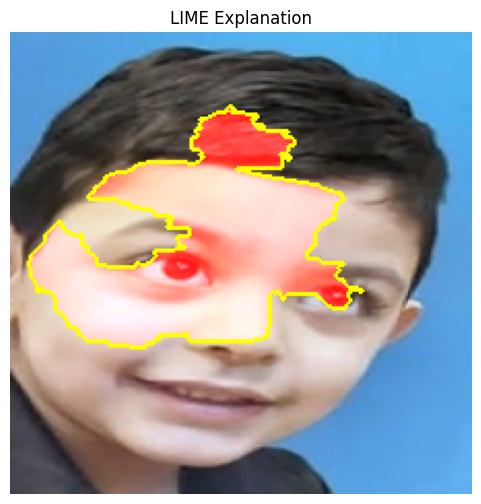

In [ ]:
explain("/content/drive/MyDrive/Graduation Project/face/dataset/test/autistic/001.jpg")

Loading model...


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step
Prediction: non_autistic | Probability: 0.8521672


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/st

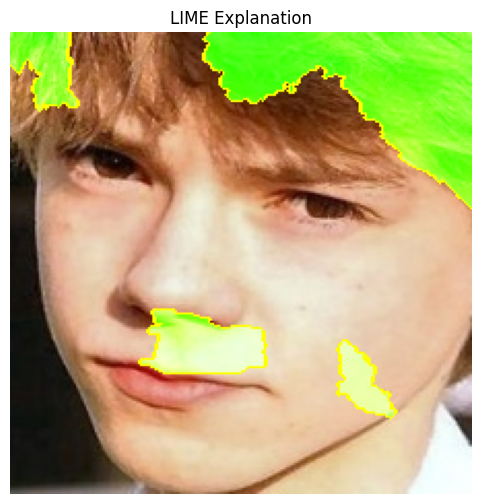

In [ ]:
explain("/content/drive/MyDrive/Graduation Project/face/dataset/test/non_autistic/010.jpg")

Loading model...


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: non_autistic | Probability: 0.93322754


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 

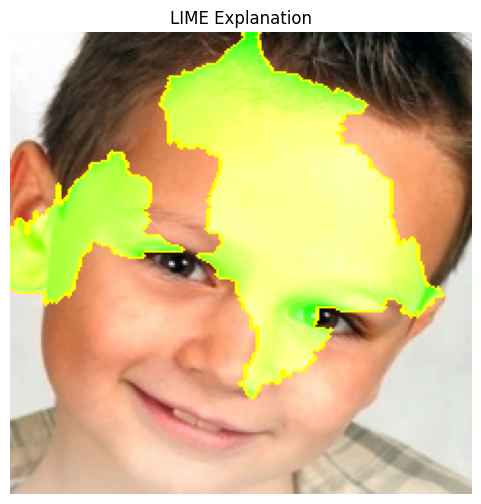

In [ ]:
explain("/content/drive/MyDrive/Graduation Project/face/dataset/test/non_autistic/001.jpg")